# Simple Linear Regression — From Scratch vs Scikit-Learn

This notebook validates the Simple Linear Regression implementation developed from first principles.

Two models are evaluated on the same training and test data:

1. A custom implementation based on the closed-form Ordinary Least Squares solution.
2. Scikit-learn's `LinearRegression` implementation.

The objective is to determine whether the custom implementation produces equivalent coefficient estimates, predictions, and evaluation metrics.

This comparison is a validation experiment rather than a replacement for understanding the underlying mathematics.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [3]:
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

str(PROJECT_ROOT)

'/Users/shyamverma/ml_projects/slr_from_ols'

In [4]:
from src.linear_regression import SimpleLinearRegression
from src.metrics import mae, mse, rmse, r2_score

In [6]:
df = pd.read_csv(PROJECT_ROOT / "data" / "raw" / "Advertising.csv")

In [7]:
X = df["TV"].values
y = df["Sales"].values

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
custom_model = SimpleLinearRegression()

custom_model.fit(X_train, y_train)

In [10]:
custom_intercept = custom_model.intercept_
custom_slope = custom_model.coef_

print("Custom Model")
print("Intercept: ", custom_intercept)
print("Slope: ", custom_slope)

Custom Model
Intercept:  7.119638430592953
Slope:  0.046529733705443346


In [14]:
# We have reshaped the X_train data as LinearRegression Model expects the 2D array for inputs
sklearn_model = LinearRegression()

sklearn_model.fit(X_train.reshape(-1, 1), y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.05]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.12
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[1064.48]


In [15]:
sklearn_intercept = sklearn_model.intercept_
sklearn_slope = sklearn_model.coef_[0]

print("Scikit-Learn Model")
print("Intercept:", sklearn_intercept)
print("Slope:", sklearn_slope)

Scikit-Learn Model
Intercept: 7.119638430592953
Slope: 0.046529733705443346


In [17]:
coefficient_comparison = pd.DataFrame({
    "Parameter": ["Intercept", "Slope"],
    "Custom OLS": [custom_intercept, custom_slope],
    "Scikit-Learn": [sklearn_intercept, sklearn_slope]
})

coefficient_comparison

,Parameter,Custom OLS,Scikit-Learn
0,Intercept,7.119638,7.119638
1,Slope,0.046530,0.046530


In [18]:
intercept_difference = custom_intercept - sklearn_intercept
slope_difference = custom_slope - sklearn_slope

print("Intercept difference:", intercept_difference)
print("Slope difference:", slope_difference)

Intercept difference: 0.0
Slope difference: 0.0


In [19]:
np.isclose(custom_slope, sklearn_slope)

np.True_

In [21]:
custom_predictions = custom_model.predict(X_test)
sklearn_predictions = sklearn_model.predict(X_test.reshape(-1, 1))

In [22]:
prediction_comparison = pd.DataFrame({
    "Actual": y_test,
    "Custom Predictions": custom_predictions,
    "Sklearn Predictions": sklearn_predictions
})

prediction_comparison.head(10)

,Actual,Custom Predictions,Sklearn Predictions
0,16.9,14.717944,14.717944
1,22.4,16.211548,16.211548
2,21.4,20.748197,20.748197
3,7.3,7.664036,7.664036
4,24.7,17.370139,17.370139
5,12.6,10.614021,10.614021
6,22.3,17.207285,17.207285
7,8.4,9.446125,9.446125
8,11.5,17.467851,17.467851
9,14.9,15.266995,15.266995


In [26]:
prediction_difference = custom_predictions - sklearn_predictions

In [27]:
print("Maximum absolute prediction difference:")
print(np.max(np.abs(prediction_difference)))

Maximum absolute prediction difference:
0.0


In [28]:
np.allclose(custom_predictions, sklearn_predictions)

True

In [29]:
custom_metrics = {
    "MAE": mae(y_test, custom_predictions),
    "MSE": mse(y_test, custom_predictions),
    "RMSE": rmse(y_test, custom_predictions),
    "R²": r2_score(y_test, custom_predictions)
}

In [30]:
sklearn_metrics = {
    "MAE": mae(y_test, sklearn_predictions),
    "MSE": mse(y_test, sklearn_predictions),
    "RMSE": rmse(y_test, sklearn_predictions),
    "R²": r2_score(y_test, sklearn_predictions)
}

In [31]:
metrics_comparison = pd.DataFrame({
    "Metric": list(custom_metrics.keys()),
    "Custom OLS": list(custom_metrics.values()),
    "Scikit-Learn": list(sklearn_metrics.values())
})

metrics_comparison

,Metric,Custom OLS,Scikit-Learn
0,MAE,2.444420,2.444420
1,MSE,10.204654,10.204654
2,RMSE,3.194472,3.194472
3,R²,0.676695,0.676695


In [32]:
metrics_comparison["Absolute Difference"] = (metrics_comparison["Custom OLS"] - metrics_comparison["Scikit-Learn"]).abs()

metrics_comparison

,Metric,Custom OLS,Scikit-Learn,Absolute Difference
0,MAE,2.444420,2.444420,0.0
1,MSE,10.204654,10.204654,0.0
2,RMSE,3.194472,3.194472,0.0
3,R²,0.676695,0.676695,0.0


In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score as sklearn_r2_score

In [35]:
sklearn_mae = mean_absolute_error(y_test, custom_predictions)

In [36]:
sklearn_mse = mean_squared_error(y_test, custom_predictions)

In [37]:
sklearn_rmse = np.sqrt(sklearn_mse)

In [38]:
sklearn_r2 = sklearn_r2_score(y_test, custom_predictions)

In [39]:
metric_validation = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Our Implementation": [
        mae(y_test, custom_predictions),
        mse(y_test, custom_predictions),
        rmse(y_test, custom_predictions),
        r2_score(y_test, custom_predictions)
    ],
    "Scikit-Learn": [sklearn_mae, sklearn_mse, sklearn_rmse, sklearn_r2]
})

metric_validation

,Metric,Our Implementation,Scikit-Learn
0,MAE,2.444420,2.444420
1,MSE,10.204654,10.204654
2,RMSE,3.194472,3.194472
3,R²,0.676695,0.676695


In [40]:
x_line = np.linspace(X.min(), X.max(), 200)

In [41]:
custom_line = custom_model.predict(x_line)

In [42]:
sklearn_line = sklearn_model.predict(x_line.reshape(-1, 1))

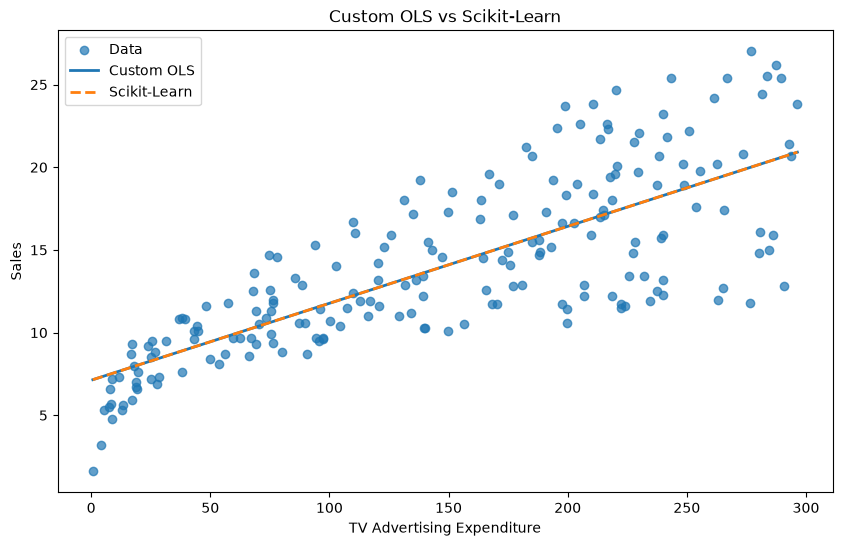

In [43]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X,
    y,
    alpha=0.7,
    label="Data"
)

plt.plot(
    x_line,
    custom_line,
    linewidth=2,
    label="Custom OLS"
)

plt.plot(
    x_line,
    sklearn_line,
    linestyle="--",
    linewidth=2,
    label="Scikit-Learn"
)

plt.xlabel("TV Advertising Expenditure")
plt.ylabel("Sales")
plt.title("Custom OLS vs Scikit-Learn")
plt.legend()

plt.show()

In [44]:
custom_residuals = y_test - custom_predictions
sklearn_residuals = y_test - sklearn_predictions

In [45]:
print("Maximum residual difference:", np.max(np.abs(custom_residuals - sklearn_residuals)))

Maximum residual difference: 0.0


In [46]:
validation_summary = {
    "Coefficients match": np.isclose(
        custom_slope,
        sklearn_slope
    ),

    "Intercepts match": np.isclose(
        custom_intercept,
        sklearn_intercept
    ),

    "Predictions match": np.allclose(
        custom_predictions,
        sklearn_predictions
    ),

    "Metrics match": np.allclose(
        list(custom_metrics.values()),
        list(sklearn_metrics.values())
    )
}

pd.Series(validation_summary)

Coefficients match    True
Intercepts match      True
Predictions match     True
Metrics match         True
dtype: bool

## Conclusion

The Simple Linear Regression implementation developed from first principles produces coefficient estimates and predictions that agree with scikit-learn's `LinearRegression` implementation up to floating-point numerical precision.

The validation provides evidence that:

1. The closed-form OLS slope calculation was implemented correctly.
2. The intercept calculation was implemented correctly.
3. The prediction function correctly applies the fitted linear equation.
4. The custom evaluation metrics agree with standard implementations.
5. The fitted regression line is numerically equivalent to the scikit-learn solution.

This experiment demonstrates that the custom implementation is not simply reproducing the API of a machine-learning library; it independently implements the mathematical OLS solution and validates it against a trusted reference implementation.